# Lab Assignment 5 — Multiclass Classification

## Imports and Setup

In [1]:
# Run this cell once if ucimlrepo is not installed
# !pip install ucimlrepo

import matplotlib
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## Task 1 — Data Acquisition and Exploration

### 1.1 Download and Load the Dataset

In [2]:
# Fetch the Vertebral Column dataset from UCI
vertebral_column = fetch_ucirepo(id=212)

# Load features and target
X = vertebral_column.data.features.copy()
y = vertebral_column.data.targets.copy()

# Combine for exploration
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia


### 1.2 Dataset Information

In [3]:
print("Number of samples:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFeature names:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.columns.tolist())

print("\nData types:")
display(df.dtypes)


Number of samples: 310
Number of columns: 7

Feature names:
['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis']

Target column:
['class']

Data types:


pelvic_incidence            float64
pelvic_tilt                 float64
lumbar_lordosis_angle       float64
sacral_slope                float64
pelvic_radius               float64
degree_spondylolisthesis    float64
class                        object
dtype: object

### 1.3 Summary Statistics — Mean, Median and Standard Deviation

In [4]:
summary_statistics = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Standard Deviation": X.std(),
    "Minimum": X.min(),
    "Maximum": X.max()
})

display(summary_statistics)


,Mean,Median,Standard Deviation,Minimum,Maximum
pelvic_incidence,60.496653,58.691038,17.236520,26.147921,129.834041
pelvic_tilt,17.542822,16.357689,10.008330,-6.554948,49.431864
lumbar_lordosis_angle,51.930930,49.562398,18.554064,14.000000,125.742385
sacral_slope,42.953831,42.404912,13.423102,13.366931,121.429566
pelvic_radius,117.920655,118.268178,13.317377,70.082575,163.071041
degree_spondylolisthesis,26.296694,11.767934,37.559027,-11.058179,418.543082


### 1.4 Check for Missing Values

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

if missing_values.sum() == 0:
    print("No missing values found.")


Missing values in each column:


pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

No missing values found.


### 1.5 Check for Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 0
No duplicate rows found.


### 1.6 Detect Potential Outliers Using IQR

In [7]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (X < lower_bound) | (X > upper_bound)
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("Potential outliers in each feature:")
display(outlier_counts.to_frame("Outlier Count"))


Potential outliers in each feature:


,Outlier Count
pelvic_tilt,13
pelvic_radius,11
degree_spondylolisthesis,10
pelvic_incidence,3
sacral_slope,1
lumbar_lordosis_angle,1


### 1.7 Handle Potential Outliers

Potential outliers are not automatically deleted because extreme biomechanical measurements can represent genuine patients. Instead, the preprocessing stage will use **IQR-based clipping calculated only from the training data**. This retains the observations while reducing the effect of extreme values and avoids test-set information leakage.


### 1.8 Histograms of Features

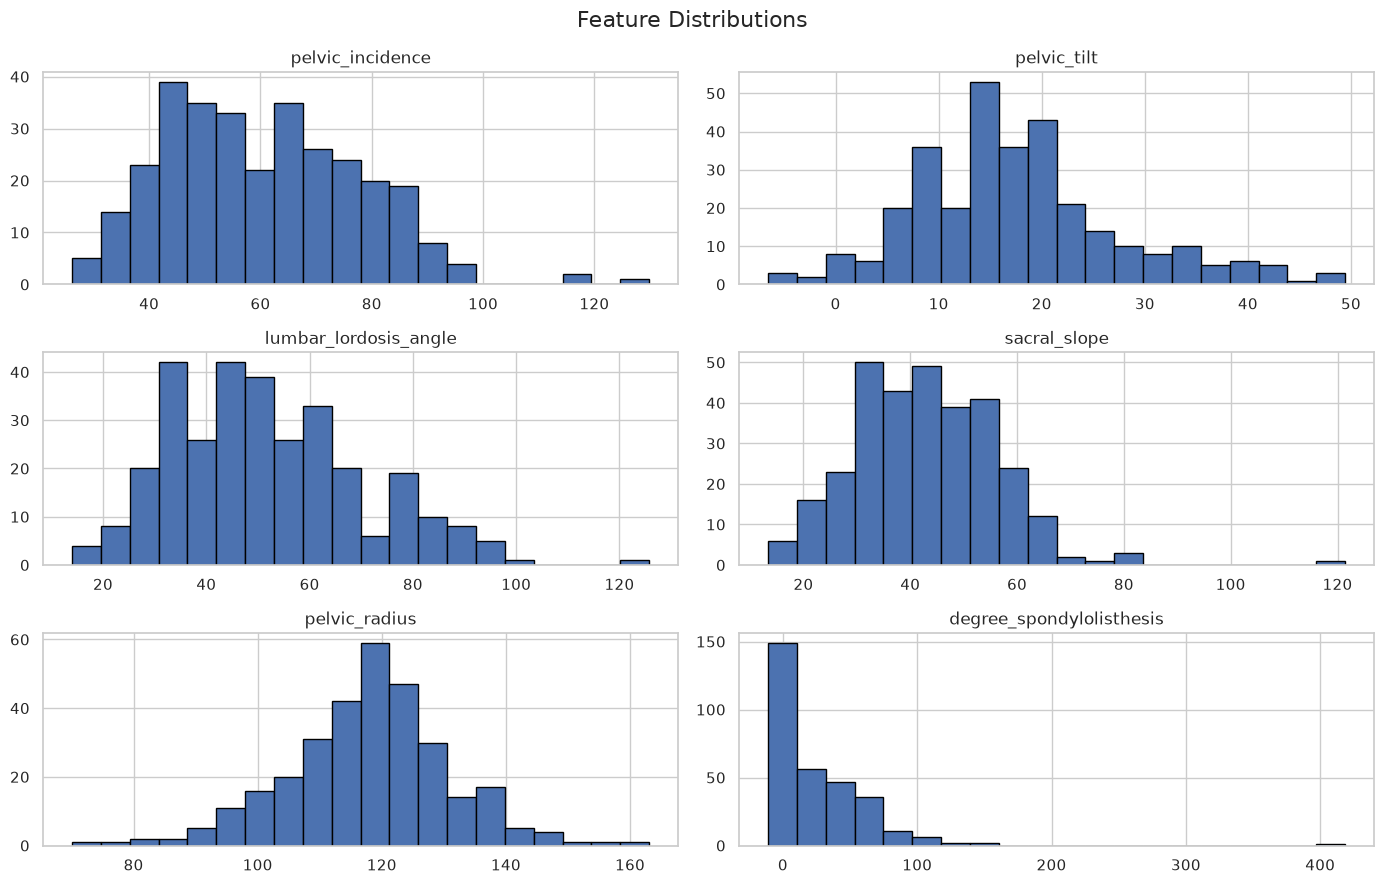

In [8]:
X.hist(
    figsize=(14, 9),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


### 1.9 Box Plots of Features

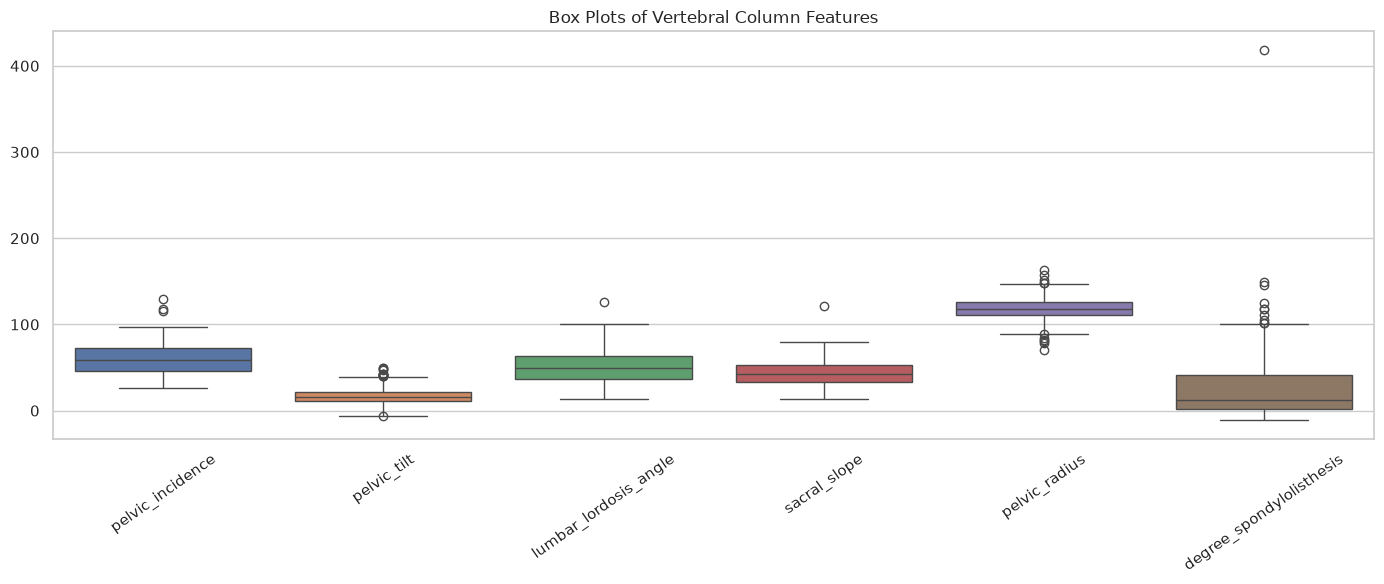

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=X)
plt.xticks(rotation=35)
plt.title("Box Plots of Vertebral Column Features")
plt.tight_layout()
plt.show()


### 1.10 Correlation Heatmap

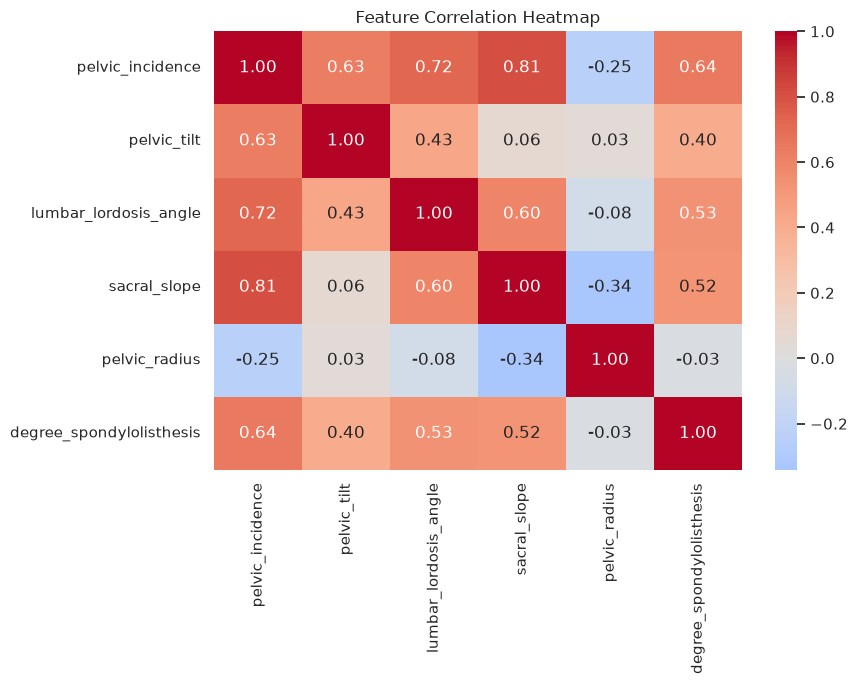

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


### 1.11 Class Distribution

Class counts:


class
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64

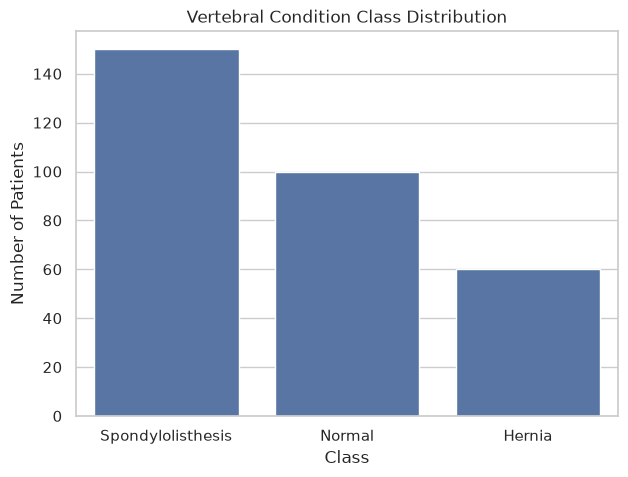

In [11]:
class_counts = y.iloc[:, 0].value_counts()

print("Class counts:")
display(class_counts)

plt.figure(figsize=(7, 5))
sns.countplot(
    x=y.iloc[:, 0],
    order=class_counts.index
)

plt.title("Vertebral Condition Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.show()


## Task 2 — Data Preprocessing

### 2.1 Encode the Target Variable

In [12]:
# Encode the target variable robustly

# Convert target to clean strings
y_clean = y.iloc[:, 0].astype(str).str.strip().str.upper()

print("Original target values:")
print(y_clean.unique())

# Handle the standard UCI labels.
# If ucimlrepo returns descriptive labels instead, normalize them here.
label_normalization = {
    "NORMAL": "NO",
    "DISK HERNIA": "DH",
    "DISK_HERNIA": "DH",
    "HERNIA": "DH",
    "SPONDYLOLISTHESIS": "SL",
    "SPONDYLOLISTHESIS ": "SL"
}

y_clean = y_clean.replace(label_normalization)

# Standard UCI 3-class encoding
class_mapping = {
    "NO": 0,
    "DH": 1,
    "SL": 2
}

y_encoded = y_clean.map(class_mapping)

# Safety check: never continue with an invalid target
if y_encoded.isna().any():
    unknown = sorted(y_clean[y_encoded.isna()].unique())
    raise ValueError(
        f"Unknown target labels found: {unknown}. "
        "Check the printed target values above."
    )

print("\nClass mapping:")
print(class_mapping)

print("\nEncoded class distribution:")
display(y_encoded.value_counts().sort_index())


Original target values:
['HERNIA' 'SPONDYLOLISTHESIS' 'NORMAL']

Class mapping:
{'NO': 0, 'DH': 1, 'SL': 2}

Encoded class distribution:


class
0    100
1     60
2    150
Name: count, dtype: int64

### 2.2 Train-Test Split Using Stratified Sampling

In [13]:
# Verify the data before stratified splitting
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)
print("Missing values in X:", X.isna().sum().sum())
print("Missing values in y:", y_encoded.isna().sum())

# Keep X and y aligned
valid_rows = y_encoded.notna()
X = X.loc[valid_rows].reset_index(drop=True)
y_encoded = y_encoded.loc[valid_rows].reset_index(drop=True)

# Final check
assert len(X) == len(y_encoded), "X and y have different numbers of rows."
assert y_encoded.isna().sum() == 0, "y_encoded still contains NaN values."

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining class proportions:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class proportions:")
display(y_test.value_counts(normalize=True).sort_index())


X shape: (310, 6)
y shape: (310,)
Missing values in X: 0
Missing values in y: 0
Training set shape: (248, 6)
Testing set shape : (62, 6)

Training class proportions:


class
0    0.322581
1    0.193548
2    0.483871
Name: proportion, dtype: float64


Testing class proportions:


class
0    0.322581
1    0.193548
2    0.483871
Name: proportion, dtype: float64

### 2.3 Handle Outliers Using Training-Set IQR Limits

In [14]:
# Calculate IQR limits using ONLY the training data
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

# Clip train and test using the same training-derived limits
X_train_clean = X_train.clip(
    lower=lower_train,
    upper=upper_train,
    axis=1
)

X_test_clean = X_test.clip(
    lower=lower_train,
    upper=upper_train,
    axis=1
)

print("Training-set IQR limits calculated and applied.")


Training-set IQR limits calculated and applied.


### 2.4 Standardize the Features

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Feature standardization completed.")
print("Approximate training mean:", X_train_scaled.mean())
print("Approximate training standard deviation:", X_train_scaled.std())


Feature standardization completed.
Approximate training mean: -1.1281298476029816e-16
Approximate training standard deviation: 1.0


## Task 3 — Multiclass Model Training and Evaluation

### 3.1 Define 4 Multiclass Machine Learning Models

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

print("Models selected:")
for name in models:
    print("-", name)


Models selected:
- Logistic Regression
- KNN
- Random Forest
- SVM


### 3.2 Train Logistic Regression

In [17]:
lr_model = models["Logistic Regression"]

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


### 3.3 Train K-Nearest Neighbors

In [18]:
knn_model = models["KNN"]

knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

print("KNN trained successfully.")


KNN trained successfully.


### 3.4 Train Random Forest

In [19]:
rf_model = models["Random Forest"]

rf_model.fit(X_train_clean, y_train)
rf_pred = rf_model.predict(X_test_clean)

print("Random Forest trained successfully.")


Random Forest trained successfully.


### 3.5 Train Support Vector Machine

In [20]:
svm_model = models["SVM"]

svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

print("SVM trained successfully.")


SVM trained successfully.


/home/sambhav/miniconda3/envs/mlenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 3.6 Evaluate Accuracy, Precision, Recall and F1-Score

In [21]:
predictions = {
    "Logistic Regression": lr_pred,
    "KNN": knn_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred
}

evaluation_rows = []

for name, pred in predictions.items():
    evaluation_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (Macro)": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1-Score (Macro)": f1_score(y_test, pred, average="macro", zero_division=0)
    })

results = pd.DataFrame(evaluation_rows)
display(results.round(4))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression,0.8065,0.7833,0.7444,0.7535
1,KNN,0.7419,0.7332,0.7222,0.7247
2,Random Forest,0.7903,0.7263,0.7222,0.7238
3,SVM,0.7742,0.7647,0.7222,0.7307


### 3.7 Detailed Classification Report — Logistic Regression

In [22]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Normal", "Disk Hernia", "Spondylolisthesis"],
    digits=4,
    zero_division=0
))


                   precision    recall  f1-score   support

           Normal     0.6667    0.8000    0.7273        20
      Disk Hernia     0.7500    0.5000    0.6000        12
Spondylolisthesis     0.9333    0.9333    0.9333        30

         accuracy                         0.8065        62
        macro avg     0.7833    0.7444    0.7535        62
     weighted avg     0.8118    0.8065    0.8023        62



### 3.8 Detailed Classification Report — KNN

In [23]:
print(classification_report(
    y_test,
    knn_pred,
    target_names=["Normal", "Disk Hernia", "Spondylolisthesis"],
    digits=4,
    zero_division=0
))


                   precision    recall  f1-score   support

           Normal     0.5833    0.7000    0.6364        20
      Disk Hernia     0.7273    0.6667    0.6957        12
Spondylolisthesis     0.8889    0.8000    0.8421        30

         accuracy                         0.7419        62
        macro avg     0.7332    0.7222    0.7247        62
     weighted avg     0.7590    0.7419    0.7474        62



### 3.9 Detailed Classification Report — Random Forest

In [24]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Normal", "Disk Hernia", "Spondylolisthesis"],
    digits=4,
    zero_division=0
))


                   precision    recall  f1-score   support

           Normal     0.6667    0.7000    0.6829        20
      Disk Hernia     0.5455    0.5000    0.5217        12
Spondylolisthesis     0.9667    0.9667    0.9667        30

         accuracy                         0.7903        62
        macro avg     0.7263    0.7222    0.7238        62
     weighted avg     0.7884    0.7903    0.7890        62



### 3.10 Detailed Classification Report — SVM

In [25]:
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Normal", "Disk Hernia", "Spondylolisthesis"],
    digits=4,
    zero_division=0
))


                   precision    recall  f1-score   support

           Normal     0.6154    0.8000    0.6957        20
      Disk Hernia     0.7500    0.5000    0.6000        12
Spondylolisthesis     0.9286    0.8667    0.8966        30

         accuracy                         0.7742        62
        macro avg     0.7647    0.7222    0.7307        62
     weighted avg     0.7930    0.7742    0.7743        62



### 3.11 Confusion Matrix — Logistic Regression

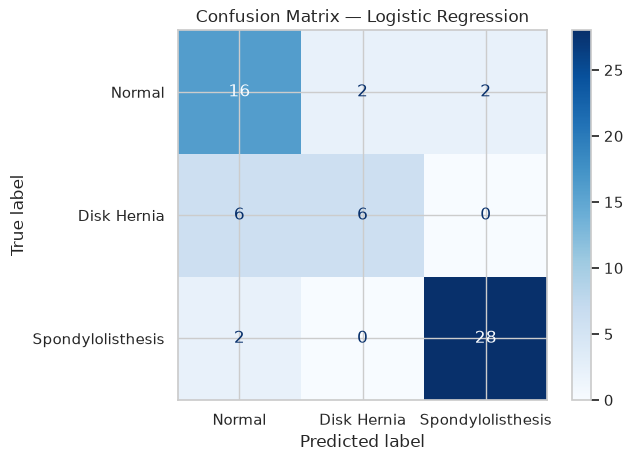

In [26]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Normal", "Disk Hernia", "Spondylolisthesis"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


### 3.12 Confusion Matrix — KNN

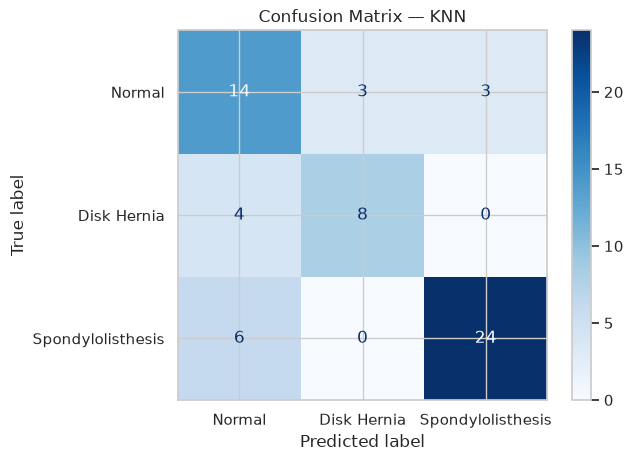

In [27]:
cm_knn = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Normal", "Disk Hernia", "Spondylolisthesis"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — KNN")
plt.show()


### 3.13 Confusion Matrix — Random Forest

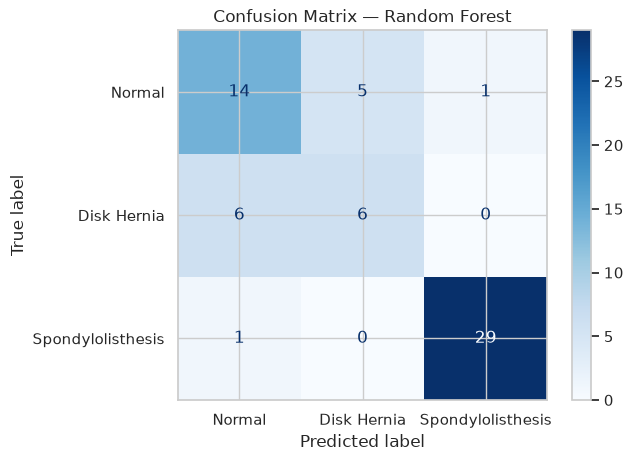

In [28]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Disk Hernia", "Spondylolisthesis"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.show()


### 3.14 Confusion Matrix — SVM

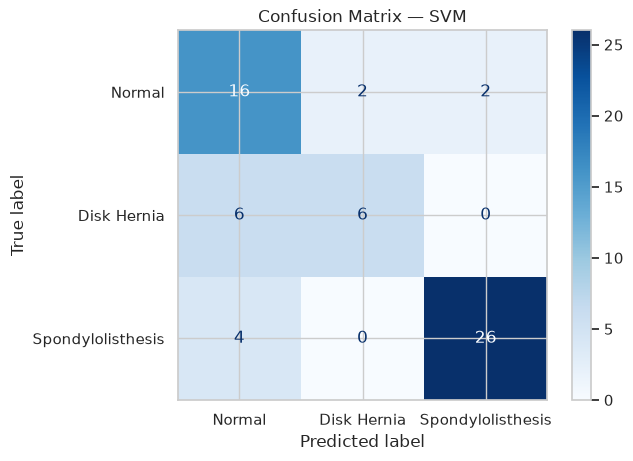

In [29]:
cm_svm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Normal", "Disk Hernia", "Spondylolisthesis"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — SVM")
plt.show()


### 3.15 Prepare Multiclass ROC-AUC Data

In [30]:
# Convert test labels to one-vs-rest binary format
classes = np.array([0, 1, 2])
y_test_binarized = label_binarize(y_test, classes=classes)

model_objects = {
    "Logistic Regression": lr_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

model_inputs = {
    "Logistic Regression": X_test_scaled,
    "KNN": X_test_scaled,
    "Random Forest": X_test_clean,
    "SVM": X_test_scaled
}

roc_probabilities = {}

for name, model in model_objects.items():
    roc_probabilities[name] = model.predict_proba(model_inputs[name])

print("Probability predictions generated for all models.")


Probability predictions generated for all models.


### 3.16 ROC Curves for All Models

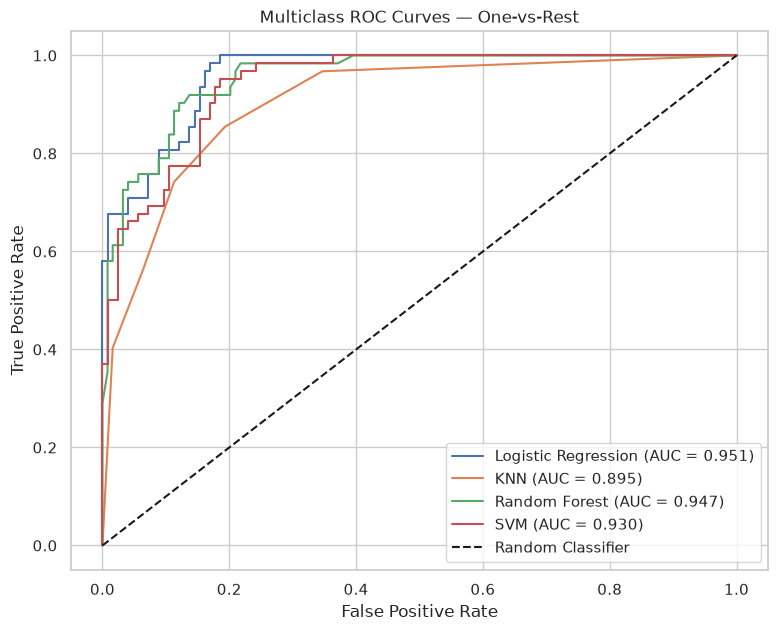

In [31]:
plt.figure(figsize=(9, 7))

for name, probabilities in roc_probabilities.items():
    # Macro-average multiclass ROC-AUC
    macro_auc = roc_auc_score(
        y_test_binarized,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

    # Compute a single micro-average ROC curve for visualization
    fpr, tpr, _ = roc_curve(
        y_test_binarized.ravel(),
        probabilities.ravel()
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {macro_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves — One-vs-Rest")
plt.legend()
plt.show()


### 3.17 Calculate Multiclass ROC-AUC for Every Model

In [32]:
auc_rows = []

for name, probabilities in roc_probabilities.items():
    macro_auc = roc_auc_score(
        y_test_binarized,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

    weighted_auc = roc_auc_score(
        y_test_binarized,
        probabilities,
        multi_class="ovr",
        average="weighted"
    )

    auc_rows.append({
        "Model": name,
        "ROC-AUC (Macro)": macro_auc,
        "ROC-AUC (Weighted)": weighted_auc
    })

auc_results = pd.DataFrame(auc_rows)

display(auc_results.round(4))


,Model,ROC-AUC (Macro),ROC-AUC (Weighted)
0,Logistic Regression,0.9507,0.9579
1,KNN,0.8952,0.9024
2,Random Forest,0.9465,0.9566
3,SVM,0.9296,0.9357


### 3.18 Final Model Comparison

In [33]:
final_results = results.merge(
    auc_results,
    on="Model"
)

display(final_results.round(4))


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC-AUC (Macro),ROC-AUC (Weighted)
0,Logistic Regression,0.8065,0.7833,0.7444,0.7535,0.9507,0.9579
1,KNN,0.7419,0.7332,0.7222,0.7247,0.8952,0.9024
2,Random Forest,0.7903,0.7263,0.7222,0.7238,0.9465,0.9566
3,SVM,0.7742,0.7647,0.7222,0.7307,0.9296,0.9357
